# Loan Tap Case Study

## Based on the features given in the dataset, the problem is to determine if a credit line should be extended to them, if so, then what should be the repayment terms?

## In the given data set, there are 27 features given, and based on my initial understanding, below forms the core pillars of the data:
- Loan Details: loan_amt,term,int_rate,installment
- Risk Buckets: grade and sub_grade
- Debt Profile : It represents typical 3 Cs of credit: Capacity (How much you can handle?), Conditions (how the credit is being used?) , Collateral (what applicant owns?) and is represented by
- The Borrower's Stability: emp_length,home_ownership,annual_inc,verification_status
- Red Flags - pub_rec,pub_rec_bankruptcies
- Target - loan_status

## Loading the dataset and statisical summary

In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, fbeta_score, roc_curve,roc_auc_score,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import math


In [ ]:
# Importing the loantap dataset
data = pd.read_csv('/content/drive/MyDrive/1. Rahul/Training/Scalar_Data_Science&ML/4.Business_Case_Study/loan_tap.csv')

In [ ]:
data.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [ ]:
# Exploring shape of the dataset

data.shape

(396030, 27)

In [ ]:
# Columns data types and null_values

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [ ]:
# As we can see that there are some null values in the dataset, lets look at the proportion of these

null_values_prop = pd.DataFrame({'Null_Values' : pd.isna(data).sum(),'Total_Values' : data.shape[0],'Null_Values_Proportion' : np.round(pd.isna(data).sum()/data.shape[0],2)*100})
null_values_prop[null_values_prop['Null_Values_Proportion']>0]

,Null_Values,Total_Values,Null_Values_Proportion
emp_title,22927,396030,6.0
emp_length,18301,396030,5.0
mort_acc,37795,396030,10.0


In [ ]:
# We will treat the null values during data pre processing

In [ ]:
# Inference from the info table:

# Pre-process emp_length: Convert the employment length into a consistent numerical format.
# Convert grade and sub_grade: As you noted, these risk factors need to be converted to numerical values.
# Handle Date Features: Extract meaningful numerical features from date columns like issue_d and earliest_cr_line.
# Encode other Categorical Features: Convert remaining categorical 'object' type columns into numerical representations.
# Address High Cardinality/Irrelevant Features: Decide how to handle features like emp_title, title, and address, which might be dropped or require advanced feature engineering.
# Define and Encode Target Variable: Prepare the loan_status column as our numerical target for prediction.

In [ ]:
# Statistical summary:

data.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [ ]:
# Inferences from statisical summary

# Loan Amount: The average loan amount is 14113 with a range of 500 to 40000. It has median of 12000 and standard deviation of 8357 which indicates that there are high variances in the data
# Int_rate: It has mean of 13.63 and median of 13.3 which indicates that there are no outliers and variance is less, but it ranges from 5-30, would be interesting to see the applicants who are in the max interest rate bucket
# Installment: The average installment is around 431.85, ranging from 16.08 to 1533.81. The mean is slightly higher than the median (375.43), suggesting a slight right skew, but generally, the values are spread out, indicating varied loan sizes.
# Annual Income (annual_inc): The average annual income is approximately 74,203.18, but the median is 64,000.00, and the maximum is significantly high at 8,706,582.00. This large difference between the mean and median, and the extremely high max value, strongly suggests a significant right skew and the presence of extreme outliers in annual income.
# Debt-to-Income Ratio (dti): The average DTI is 17.38, with a median of 16.91. The minimum is 0, and the maximum is 9999.00. The max value is an extreme outlier, indicating potential data entry issues or highly unusual cases. The mean and median are close, suggesting a relatively symmetric distribution for the majority of the data, but the outliers need attention.
# Open Accounts (open_acc): The mean is 11.31 and the median is 10. The range is from 0 to 90. The values seem reasonable, with a slight right skew due to the higher maximum, but generally, it indicates a varying number of open credit lines.
# Public Records (pub_rec): The mean is 0.18, and the median is 0. The maximum is 86.0. The high number of zeros and a mean much greater than the median (due to few high values) indicate a heavily right-skewed distribution, with many borrowers having no public records, but a few having a significantly high number, potentially outliers.
# Revolving Balance (revol_bal): The mean is 15,844.54, and the median is 11,181.00. The maximum is 1,743,266.00. Similar to annual_inc, the large difference between mean and median and the very high maximum suggest a significant right skew and the presence of extreme outliers in revolving balance.
# Revolving Utilization (revol_util): The mean is 53.79, and the median is 54.80. The values range from 0.0 to 892.3. The mean and median are very close, indicating a fairly symmetric distribution for most of the data. However, the maximum value of 892.3 is an outlier, as utilization typically doesn't exceed 100% (though it can in some specific reporting contexts, it's unusually high here).
# Total Accounts (total_acc): The mean is 25.41, and the median is 24. The range is from 2 to 151. The mean and median are close, suggesting a relatively balanced distribution, with no apparent extreme skewness for the general population.
# Mortgage Accounts (mort_acc): The mean is 1.79, and the median is 1.0. The maximum is 34.0. The median being lower than the mean, and a maximum of 34, indicates a right-skewed distribution, with many borrowers having 0 or 1 mortgage account, and a few having a much higher number.
# Public Record Bankruptcies (pub_rec_bankruptcies): The mean is 0.12, and the median is 0. The maximum is 8.0. Like pub_rec, a heavily right-skewed distribution is observed, with most borrowers having no bankruptcies, but a few having some.

In [ ]:
# Exploring Categorical Features

#term

print("Number of unique values",data['term'].nunique())
print("Counts under each unique values",(data['term'].value_counts(normalize = True))*100)

Number of unique values 2
Counts under each unique values term
36 months    76.258112
60 months    23.741888
Name: proportion, dtype: float64


In [ ]:
# Majority of the terms (76%) belongs to 36 months

In [ ]:
# grade

print("Number of unique values",data['grade'].nunique())
print("Counts under each unique values",(data['grade'].value_counts(normalize = True))*100)

Number of unique values 7
Counts under each unique values grade
B    29.295255
C    26.762366
A    16.207611
D    16.040199
E     7.950913
F     2.972502
G     0.771154
Name: proportion, dtype: float64


In [ ]:
# Grade B&C together consitutes 55% of the data, but A is high risk or low risk, to understand better lets look at the cases

In [ ]:
data[data['grade'] == 'G'].head(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
87,30000.0,60 months,24.70,875.28,G,G1,Medtronic,5 years,MORTGAGE,187321.0,...,21.0,0.0,54810.0,93.4,52.0,f,INDIVIDUAL,3.0,0.0,"25281 Kevin Neck\r\nArmstrongton, TN 29597"
97,13400.0,60 months,25.83,399.86,G,G2,DESIGNER,10+ years,MORTGAGE,56000.0,...,23.0,0.0,28845.0,84.5,44.0,w,INDIVIDUAL,6.0,0.0,"0326 Jacob Via\r\nJacksonstad, MI 93700"
133,13075.0,60 months,27.31,401.68,G,G2,Clerk-specialist level,10+ years,MORTGAGE,54777.0,...,4.0,0.0,3845.0,59.2,27.0,f,INDIVIDUAL,2.0,0.0,1532 Gill Greens Apt. 236\r\nSouth Cassandrafu...
168,11800.0,60 months,28.99,374.49,G,G5,NaN,NaN,RENT,44011.0,...,9.0,1.0,6313.0,67.2,13.0,f,INDIVIDUAL,0.0,1.0,3019 Smith Manors Suite 402\r\nLake Anthonybur...
204,34350.0,60 months,28.99,1090.13,G,G5,Quality improvement data analyst,3 years,RENT,84000.0,...,11.0,1.0,8400.0,85.7,23.0,w,INDIVIDUAL,0.0,1.0,"5050 Gomez Mill Suite 557\r\nEast Adamton, SD ..."


In [ ]:
data[data['grade'] == 'A'].head(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
6,18000.0,36 months,5.32,542.07,A,A1,Software Development Engineer,2 years,MORTGAGE,125000.0,...,8.0,0.0,4178.0,4.9,25.0,f,INDIVIDUAL,3.0,0.0,"1008 Erika Vista Suite 748\r\nEast Stephanie, ..."
14,25975.0,36 months,6.62,797.53,A,A2,Pullman Regional Hospital,9 years,MORTGAGE,65000.0,...,9.0,0.0,5140.0,7.2,35.0,f,INDIVIDUAL,6.0,0.0,"0472 Weber Manors Apt. 660\r\nLake Andrew, NH ..."
15,18000.0,36 months,8.39,567.30,A,A5,firefighter,8 years,MORTGAGE,45000.0,...,5.0,0.0,551.0,11.7,23.0,w,INDIVIDUAL,4.0,0.0,"11629 Sean Hills Suite 614\r\nStevenfort, HI 3..."
18,34000.0,36 months,7.90,1063.87,A,A4,Pilot,10+ years,RENT,130580.0,...,16.0,0.0,8767.0,11.9,36.0,f,INDIVIDUAL,3.0,0.0,"254 Mary Ferry\r\nPort Kirstenborough, CO 70466"


In [ ]:
# Looking at both the extremes its clear that risk is sorted in ascending startin from A to G

In [ ]:
# sub-grade

data['sub_grade'].nunique()

35

In [ ]:
# home-ownership

print("Number of unique values",data['home_ownership'].nunique())
print("Counts under each unique values",(data['home_ownership'].value_counts(normalize = True))*100)

Number of unique values 6
Counts under each unique values home_ownership
MORTGAGE    50.084085
RENT        40.347953
OWN          9.531096
OTHER        0.028281
NONE         0.007828
ANY          0.000758
Name: proportion, dtype: float64


In [ ]:
# 90% of the applicants have either mortaged property or rented property

In [ ]:
# vertification status

print("Number of unique values",data['verification_status'].nunique())
print("Counts under each unique values",(data['verification_status'].value_counts(normalize = True))*100)

Number of unique values 3
Counts under each unique values verification_status
Verified           35.240512
Source Verified    33.175517
Not Verified       31.583971
Name: proportion, dtype: float64


In [ ]:
# There are equal distributions between all 3 categories

In [ ]:
# purpose

print("Number of unique values",data['purpose'].nunique())
print("Counts under each unique values",(data['purpose'].value_counts(normalize = True))*100)

Number of unique values 14
Counts under each unique values purpose
debt_consolidation    59.214453
credit_card           20.962806
home_improvement       6.067722
other                  5.349342
major_purchase         2.219529
small_business         1.439537
car                    1.186021
medical                1.059516
moving                 0.720652
vacation               0.619145
house                  0.555766
wedding                0.457541
renewable_energy       0.083075
educational            0.064894
Name: proportion, dtype: float64


In [ ]:
# 70% of the applicants used their loan either for debt consolidation and credit_card

In [ ]:
# initial_list_status

print("Number of unique values",data['initial_list_status'].nunique())
print("Counts under each unique values",(data['initial_list_status'].value_counts(normalize = True))*100)

Number of unique values 2
Counts under each unique values initial_list_status
f    60.113123
w    39.886877
Name: proportion, dtype: float64


In [ ]:
# application_type

print("Number of unique values",data['application_type'].nunique())
print("Counts under each unique values",(data['application_type'].value_counts(normalize = True))*100)

Number of unique values 3
Counts under each unique values application_type
INDIVIDUAL    99.820468
JOINT          0.107315
DIRECT_PAY     0.072217
Name: proportion, dtype: float64


In [ ]:
# Almost all the applicants are individual applicants

In [ ]:
# Based on the above analysis, the following encoding methods would be used, but will do post EDA:


# 1. Ordinal : term, grade, sub_grade, verification_status,
# 2. One-hot encoding : home_ownership, purpose, initial_list_status, application_type
# 3. Extact numerical features from issue_d and earliest_cr_line by converting them to datetime objects and deriving features like year, month or the number of months since the earliest credit line or loan issue date
# 4. Label encoding : loan_status

## Feature Engineering

### Null Value Treatment

In [ ]:
# There are 3 columns having null values out of which 2 are object data type and 1 is float 64, we have below options to treat null values
# 1. Replace with mean,mode,median or constant value
# 2. Remove them from the dataset

# Lets look at one by one

# 1. emp_title is an object data type and its very difficult to replace it with any of the aforesaid values, so will replace with "Unknown"
# 2. emp_length again it depends on the individual, but we can look at the null values data and if the values of other features are providing any pattern then will replace with a value, or best is to replace with 0
# 3. mort_acc which is the count of mortgage accounts the applicant has on their credit report, now this would be difficult to replace, as it depends on each user and not recommended to replace with any value. Hence its better to remove them.

In [ ]:
# Treating Null Values

# 1. emp_title

data['emp_title'] = data['emp_title'].fillna('Unknown')

# 2. emp_length

data['emp_length'] = data['emp_length'].fillna(0)

# 3. mort_acc

# Generally there is a connection between total_acc and mort_acc, so lets fill the null values with the
# average number of mortage accounts for people who have the same number of total credit lines

# Calculating the mean mort_acc for each total_acc
total_acc_avg = data.groupby('total_acc')['mort_acc'].mean()

# Defining custom function to replace the NaN values
def fill_mort_acc(total_acc,mort_acc):
  if np.isnan(mort_acc):
    return total_acc_avg[total_acc]
  else:
    return mort_acc

# Applying this function to the dataset

data['mort_acc'] = data.apply(lambda x: fill_mort_acc(x['total_acc'],x['mort_acc']),axis = 1)

In [ ]:
# Lets relook at the null values

# As we can see that there are some null values in the dataset, lets look at the proportion of these

null_values_prop = pd.DataFrame({'Null_Values' : pd.isna(data).sum(),'Total_Values' : data.shape[0],'Null_Values_Proportion' : np.round(pd.isna(data).sum()/data.shape[0],2)*100})
null_values_prop[null_values_prop['Null_Values_Proportion']>0]

,Null_Values,Total_Values,Null_Values_Proportion


In [ ]:
# There is no output, so all the null values are treated successfully

In [ ]:
# Fill NaN values in 'revol_util' with its median
revol_util_median = data['revol_util'].median()
data['revol_util'] = data['revol_util'].fillna(revol_util_median)

print(f"Number of null values in 'revol_util' after filling: {data['revol_util'].isnull().sum()}")

Number of null values in 'revol_util' after filling: 0


## Data Pre-processing

In [ ]:
# Converting object type to datetime object
data['issue_d'] = pd.to_datetime(data['issue_d'])
data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'])

/tmp/ipython-input-2137097726.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['issue_d'] = pd.to_datetime(data['issue_d'])
/tmp/ipython-input-2137097726.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'])


In [ ]:
# The the difference between these two dates (specifically, issue_d - earliest_cr_line), you are effectively measuring how many years or months a
# borrower has had an active credit history prior to receiving the current loan.

# the difference (length of credit history) is highly significant. A larger difference generally implies a less risky profile,
# not a riskier one, assuming that history is positive.


In [ ]:
data['credit_history_length_months'] = np.round((((data['issue_d'] - data['earliest_cr_line']).dt.days) /30) ,0)

In [ ]:
data['issued_month'] = pd.to_datetime(data['issue_d']).dt.month
data['issued_year'] = pd.to_datetime(data['issue_d']).dt.year

In [ ]:
data['credit_month'] = pd.to_datetime(data['earliest_cr_line']).dt.month
data['credit_year'] = pd.to_datetime(data['earliest_cr_line']).dt.year

In [ ]:
data.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address',
       'credit_history_length_months', 'issued_month', 'issued_year',
       'credit_month', 'credit_year'],
      dtype='object')

In [ ]:
# Flags Creation for pub_rec_bankruptcies

data['pub_rec_bankruptcies'] = data['pub_rec_bankruptcies'].apply(lambda x: 1 if x > 1 else 0)
data['pub_rec_bankruptcies'].value_counts()

,count
pub_rec_bankruptcies,
0,393705
1,2325


In [ ]:
# Flags Creation for mort_acc

data['mort_acc'] = data['mort_acc'].apply(lambda x: 1 if x >1 else 0)
data['mort_acc'].value_counts()

,count
mort_acc,
0,212225
1,183805


In [ ]:
# Flags Creation for pub_rec


# Flags Creation for mort_acc

data['pub_rec'] = data['pub_rec'].apply(lambda x: 1 if x >1 else 0)
data['pub_rec'].value_counts()


,count
pub_rec,
0,388011
1,8019


## EDA

### Outlier Treatment

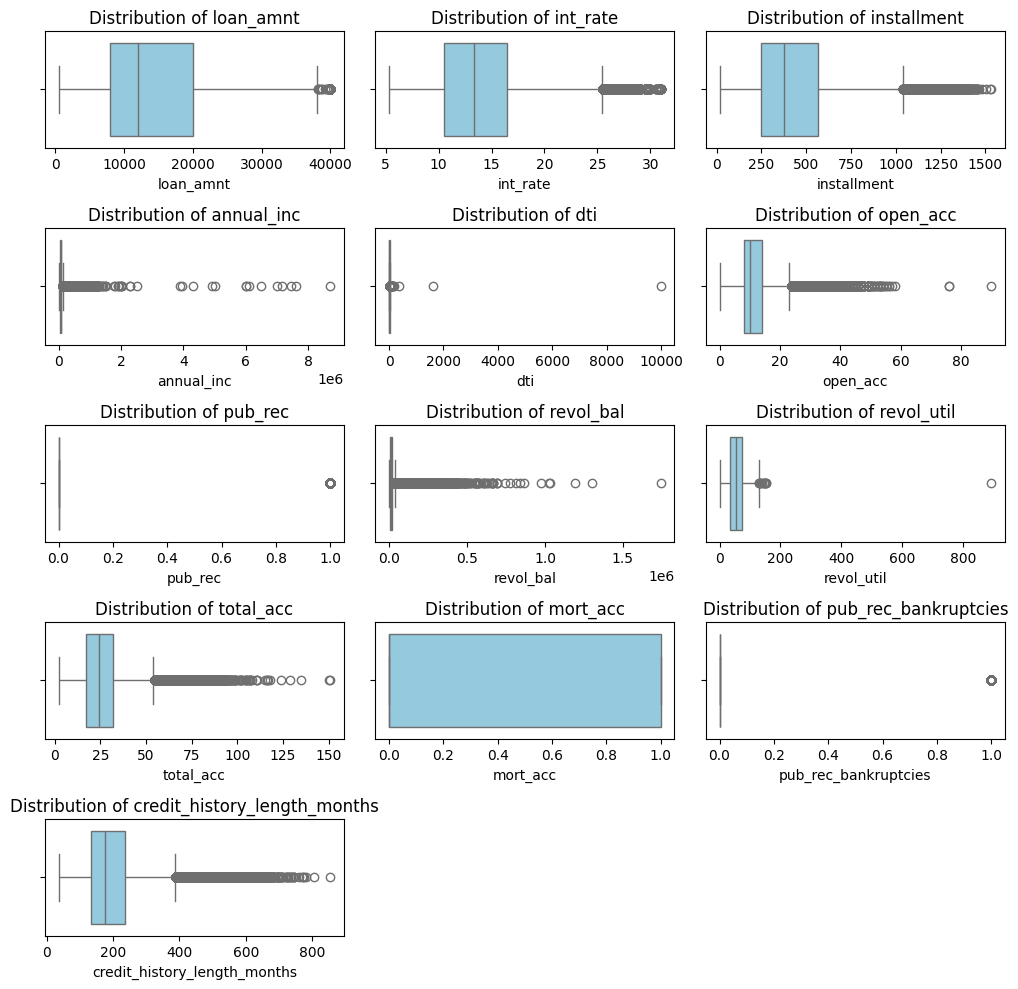

In [ ]:
num_features = data.select_dtypes(include = ['int64','float64']).columns
num_features

n_featuress = len(num_features)
col = 3
rows = math.ceil(n_featuress / col)

fig,axes = plt.subplots(rows,col,figsize = (10,10))
axes = axes.flatten()

for i,feature in enumerate(num_features):
  sns.boxplot(data, x = feature, ax = axes[i], color='skyblue')
  axes[i].set_title(f'Distribution of {feature}', fontsize = 12)

for j in range(i+1,len(axes)):
  axes[j].axis('off') # Corrected: Call 'axis' as a method

plt.tight_layout()
plt.show()

In [ ]:
def outlier_treatment(data,feature):
  q1 = np.percentile(data[feature],0.25)
  q3 = np.percentile(data[feature],0.75)
  iqr = q3-q1

  lower_bound = q1-(1.5*iqr)
  upper_bound = q3+(1.5*iqr)

  data_points_below_lower_bound = len(data[data[feature] < lower_bound]) / len(data) * 100
  data_points_above_upper_bound = len(data[data[feature] > upper_bound]) / len(data) * 100

  return lower_bound,upper_bound, data_points_below_lower_bound,data_points_above_upper_bound

In [ ]:
for i in num_features:
  # outlier_treatment(data,i)
  print(f'Critical metrics for {i}')
  print(f'The lower bound value of {i} is', np.round(outlier_treatment(data,i)[0],2))
  print(f'The upper bound value of {i} is', np.round(outlier_treatment(data,i)[1],2))
  print(f'The % of values below lower bound of {i} is', np.round(outlier_treatment(data,i)[2],2))
  print(f'The % of values below upper bound of {i} is', np.round(outlier_treatment(data,i)[3],2))
  print('\n')

Critical metrics for loan_amnt
The lower bound value of loan_amnt is 250.0
The upper bound value of loan_amnt is 2250.0
The % of values below lower bound of loan_amnt is 0.0
The % of values below upper bound of loan_amnt is 97.81


Critical metrics for int_rate
The lower bound value of int_rate is 4.62
The upper bound value of int_rate is 6.49
The % of values below lower bound of int_rate is 0.0
The % of values below upper bound of int_rate is 96.28


Critical metrics for installment
The lower bound value of installment is 13.28
The upper bound value of installment is 70.61
The % of values below lower bound of installment is 0.0
The % of values below upper bound of installment is 98.07


Critical metrics for annual_inc
The lower bound value of annual_inc is 6283.39
The upper bound value of annual_inc is 24194.35
The % of values below lower bound of annual_inc is 0.01
The % of values below upper bound of annual_inc is 97.16


Critical metrics for dti
The lower bound value of dti is -0.7

In [ ]:
# Inferences:


# many features show over 90% of values above the upper bound is very insightful.
# This is a common occurrence with financial datasets where features like income,
# loan amounts, or debt ratios tend to be highly skewed (e.g., a few very high values
# pulling the distribution to one side). The IQR method, being sensitive to the central
# 50% of the data, can label these genuinely extreme but valid data points as 'outliers'.

# It's crucial not to simply delete these values. Doing so would remove a significant portion
# of the dataset, leading to potential loss of information and a biased model.

### Univariate Analysis

In [ ]:
data.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address',
       'credit_history_length_months', 'issued_month', 'issued_year',
       'credit_month', 'credit_year'],
      dtype='object')

In [ ]:
# Recalling numerical features which was derived earlier
num_features

Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies', 'credit_history_length_months'],
      dtype='object')

In [ ]:
# Since we converted 3 columns to 1 and 0, hence taking removing those and adding it to cat features

num_features = num_features.drop(['pub_rec','pub_rec_bankruptcies','mort_acc'])

In [ ]:
# Grouping categorica features

cat_features = data.select_dtypes(include = ['object']).columns

In [ ]:
cat_features

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'loan_status', 'purpose',
       'title', 'initial_list_status', 'application_type', 'address'],
      dtype='object')

In [ ]:
# There are some features which dont add value to the overall data due to high cardinality hence dropping them

# Re-initialize cat_features to ensure it contains all current object columns
cat_features = data.select_dtypes(include = ['object']).columns

# Now, drop the high-cardinality features, ignoring errors if some are already gone
cat_features = cat_features.drop(['emp_title','address','title'], errors='ignore')


# Adding those features which were dropped in numerical category

# Convert the list to a Pandas Index before appending
cat_features = cat_features.append(pd.Index(['pub_rec','pub_rec_bankruptcies','mort_acc']))

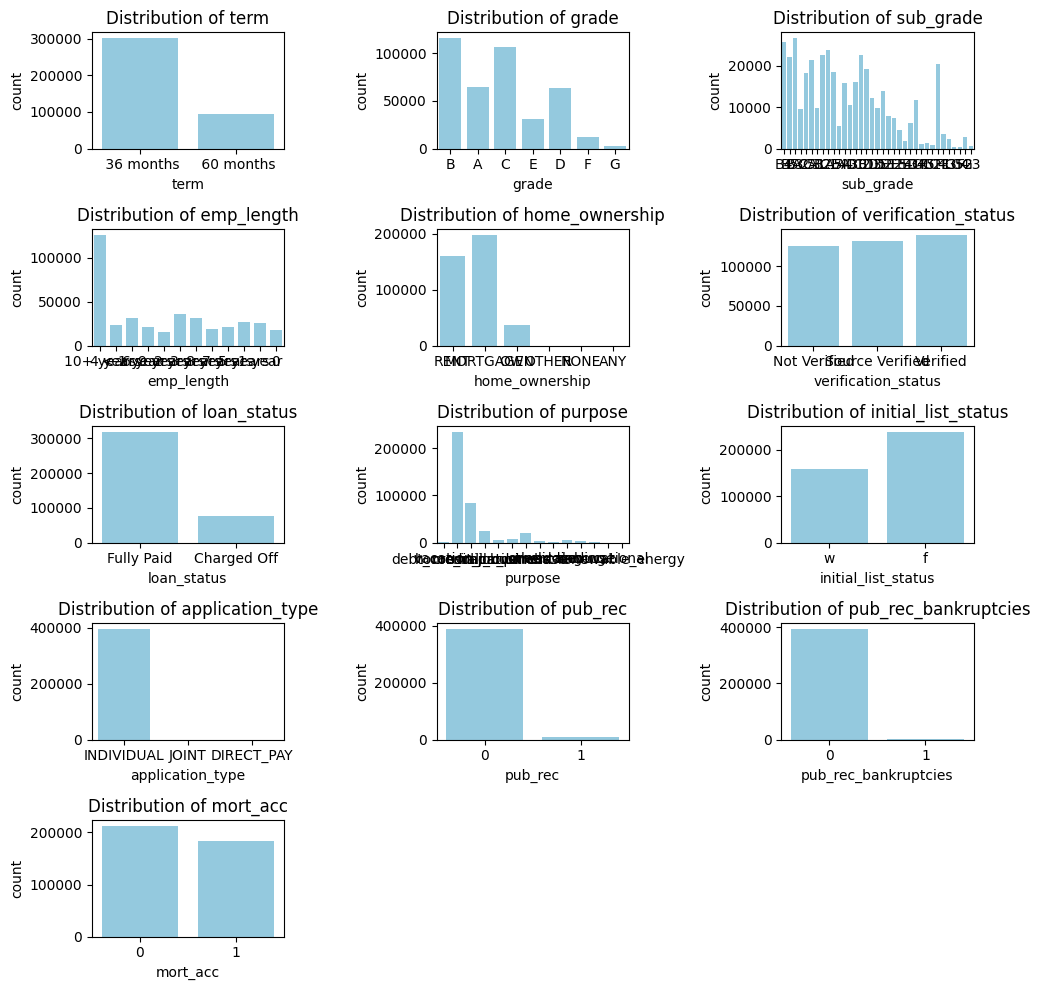

In [ ]:
# Understanding categorical variables

n_cat_features = len(cat_features)
col = 3
rows = math.ceil(n_cat_features / col)

fig,axes = plt.subplots(rows,col,figsize = (10,10))
axes = axes.flatten()

for i,features in enumerate(cat_features):
  sns.countplot(data = data, x = features, ax = axes[i],color = 'skyblue')
  axes[i].set_title(f'Distribution of {features}',fontsize = 12)

for j in range(i+1,len(axes)):
  axes[j].axis('off')

plt.tight_layout()
plt.show()

#### Inferences

 - Term: The majority of loans are for a 36-month term, significantly outweighing the 60-month term. This suggests that borrowers generally prefer shorter repayment periods, or lenders favor them.
 - Grade and Sub-Grade: The grades 'B' and 'C' are the most common, indicating that a large portion of the borrowers fall into a medium-risk category. The distribution gradually decreases towards the higher-risk grades (F, G) and lower-risk grades (A).
 - Employment Length (emp_length): A substantial number of applicants have an employment length of '10+ years', suggesting a stable employment history among a significant portion of borrowers. There's also a noticeable count for < 1 year and 0 (which we imputed for missing values).
 - Home Ownership (home_ownership): Most applicants either have a 'MORTGAGE' or 'RENT' their homes, collectively accounting for the vast majority of cases. 'OWN' is less frequent, and categories like 'OTHER', 'NONE', or 'ANY' are very rare.
 - Verification Status (verification_status): The loan applications are fairly evenly distributed across 'Verified', 'Source Verified', and 'Not Verified' statuses. This suggests no strong preference or bias in the verification process based on volume.
 - Loan Status (loan_status): This is our target variable. The plots show a clear imbalance, with a significantly higher number of 'Fully Paid' loans compared to 'Charged Off' loans. This indicates a class imbalance problem that will need to be addressed during model training.
 - Purpose (purpose): The overwhelming majority of loans are taken for 'debt_consolidation' and 'credit_card' purposes. Other purposes like home improvement, major purchase, or medical are far less common.
 - Initial List Status (initial_list_status): There are two main statuses, 'f' and 'w', with 'f' being more frequent than 'w'.
 - Application Type (application_type): Almost all loan applications are from 'INDIVIDUAL' applicants, with 'JOINT' and 'DIRECT_PAY' being very rare.

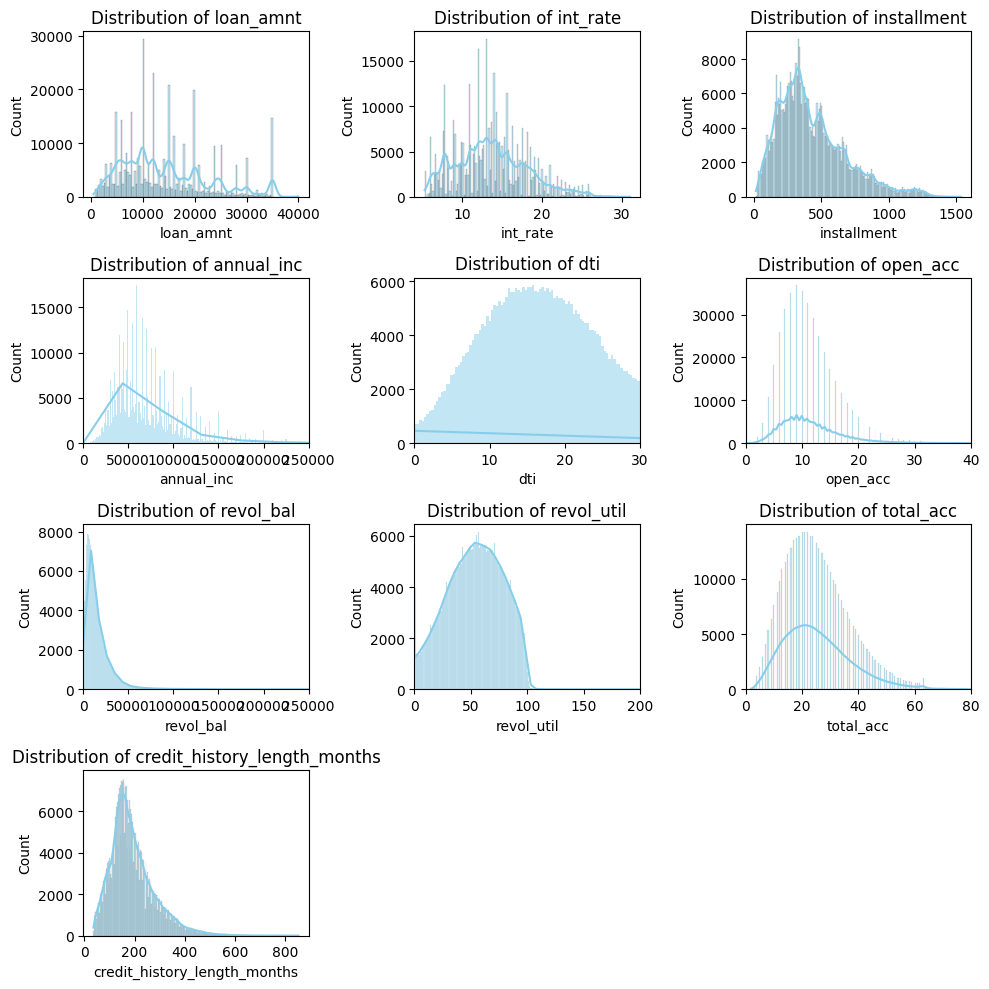

In [ ]:
# Understanding numerical variables

n_num_features = len(num_features)
col = 3
rows = math.ceil(n_num_features / col)

fig,axes = plt.subplots(rows,col,figsize = (10,10))
axes = axes.flatten()

for i,features in enumerate(num_features):
  sns.histplot(data = data, x = features, ax = axes[i],color = 'skyblue',kde = True)
  axes[i].set_title(f'Distribution of {features}',fontsize = 12)
  # Set xlim for annual_inc to better visualize its distribution
  if features == 'annual_inc':
    axes[i].set_xlim(0, 250000) # Adjust this upper limit as needed for better visualization
  if features == 'dti':
    axes[i].set_xlim(0, 30) # Adjust this upper limit as needed for better visualization\
  if features == 'open_acc':
    axes[i].set_xlim(0, 40) # Adjust this upper limit as needed for better visualization
  if features == 'revol_bal':
    axes[i].set_xlim(0, 250000) # Adjust this upper limit as needed for better visualization
  if features == 'revol_util':
    axes[i].set_xlim(0, 200) # Adjust this upper limit as needed for better visualization
  if features == 'total_acc':
    axes[i].set_xlim(0, 80) # Adjust this upper limit as needed for better visualization

for j in range(i+1,len(axes)):
  axes[j].axis('off')

plt.tight_layout()
plt.show()

#### Inferences:

 - Loan Amount (loan_amnt): The distribution suggests multiple peaks, possibly indicating common loan sizes requested by applicants. It's generally spread out, with a higher frequency at lower to mid-range amounts.
 - Interest Rate (int_rate): The distribution is somewhat bell-shaped but slightly right-skewed, with most loans falling into the 10-15% interest rate range. There's a tail extending to higher rates, indicating a segment of higher-risk borrowers.
 - Installment (installment): Similar to loan amount, the installment distribution is right-skewed, with most borrowers having lower monthly payments and fewer having very high payments.
 - Annual Income (annual_inc): This feature is highly right-skewed, with the vast majority of applicants having annual incomes below $100,000 to $$100,000 to $150,000. There are very few applicants with extremely high incomes.
 - DTI (Debt-to-Income Ratio): The DTI distribution is also right-skewed, with most applicants having a DTI between 10% and 25%. Values extend significantly higher but are less frequent.
 - Open Accounts (open_acc): Most applicants have between 5 and 15 open credit accounts, with the distribution being right-skewed, indicating fewer people with a very large number of open accounts.
 - Revolving Balance (revol_bal): This feature shows a strong right-skew, with most applicants having a relatively low revolving balance. A few individuals have very large balances, pulling the distribution to the right.
 - Revolving Utilization (revol_util): The distribution for revolving utilization appears relatively broad, but a significant portion of applicants fall within the 30% to 70% utilization range. Very high utilization (above 100% or 200%) is rare.
 - Total Accounts (total_acc): The distribution is right-skewed, with most applicants having between 15 and 30 total credit accounts. Fewer individuals have an extremely high number of total accounts.
 - Credit History Length (credit_history_length_months): This feature shows a right-skewed distribution, indicating that a large portion of applicants have a credit history length between roughly 150 and 300 months (12.5 to 25 years). Fewer applicants have very short or extremely long credit histories.

### Bi-variate analysis

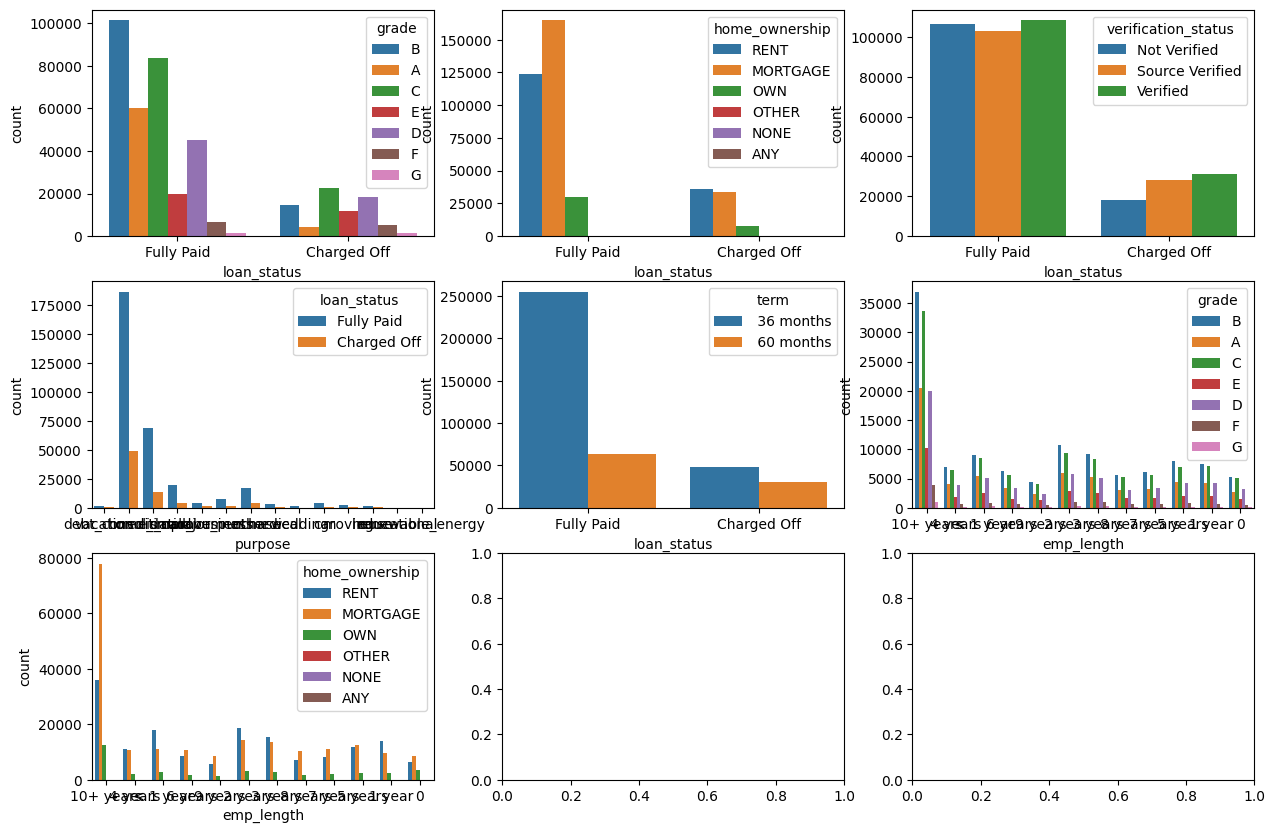

In [ ]:
# Category - Category Variable

plt.subplots(3,3,figsize = (15,10))

# Loan Status & Grade

plt.subplot(3,3,1)
sns.countplot(data = data,x = 'loan_status',hue = 'grade')

# Loan Status & Home Ownership
plt.subplot(3,3,2)
sns.countplot(data = data,x = 'loan_status',hue = 'home_ownership')

# Loan Status & Verification Status
plt.subplot(3,3,3)
sns.countplot(data = data,x = 'loan_status',hue = 'verification_status')

# Loan Status & Purpose
plt.subplot(3,3,4)
sns.countplot(data = data,x = 'purpose',hue = 'loan_status')

# Loan Status & term distribution
plt.subplot(3,3,5)
sns.countplot(data = data,x = 'loan_status',hue = 'term')

# Employee Length & Grade
plt.subplot(3,3,6)
sns.countplot(data = data,x = 'emp_length',hue = 'grade')

# Employee Home ownership and emp lengnth
plt.subplot(3,3,7)
sns.countplot(data = data,x = 'emp_length',hue = 'home_ownership')

plt.show()


#### Inferences:

 - Loan Status vs. Grade: Loans with lower grades (e.g., F, G) show a visibly higher proportion of 'Charged Off' loans compared to higher grades (A, B, C). This reinforces that loan grade is a strong indicator of default risk.
 - Loan Status vs. Home Ownership: 'RENT' and 'MORTGAGE' categories have the highest absolute numbers for both 'Fully Paid' and 'Charged Off' loans, simply because they represent the majority of applicants. To truly assess risk, one would need to look at the proportion of charged-off loans within each category, but visually, there doesn't seem to be a drastic difference in the ratio of charged off to fully paid across these main categories.
 - Loan Status vs. Verification Status: The distribution of 'Charged Off' vs. 'Fully Paid' appears relatively consistent across 'Verified', 'Source Verified', and 'Not Verified' statuses. This suggests that the verification status alone might not be a dominant predictor of loan default rates.
 - Loan Status vs. Purpose: 'Debt Consolidation' and 'Credit Card' purposes have the highest absolute counts of 'Charged Off' loans, mirroring their high overall frequency. It would be important to analyze the percentage of charged-off loans within each purpose to understand true risk per purpose.
 - Loan Status vs. Term Distribution: The 60-month term loans appear to have a higher proportion of 'Charged Off' cases relative to 'Fully Paid' compared to the 36-month term loans. This implies that longer loan terms might carry higher default risk.
 - Employment Length vs. Grade: There seems to be a tendency for applicants with longer employment lengths (e.g., '10+ years') to be associated with better loan grades (A, B, C), while shorter employment lengths (e.g., '< 1 year') are more spread across various grades but might include a higher proportion of lower grades.
 - Home Ownership vs. Employment Length: Applicants with 'MORTGAGE' and 'OWN' home ownership tend to have longer employment histories ('10+ years' being dominant), while 'RENT' is more distributed across all employment lengths, including shorter ones.

In [ ]:
pd.Series(data.select_dtypes(include = ['int64','float64']).columns)

,0
0,loan_amnt
1,int_rate
2,installment
3,annual_inc
4,dti
5,open_acc
6,pub_rec
7,revol_bal
8,revol_util
9,total_acc


Text(0.5, 1.0, 'Debt-to-Income')

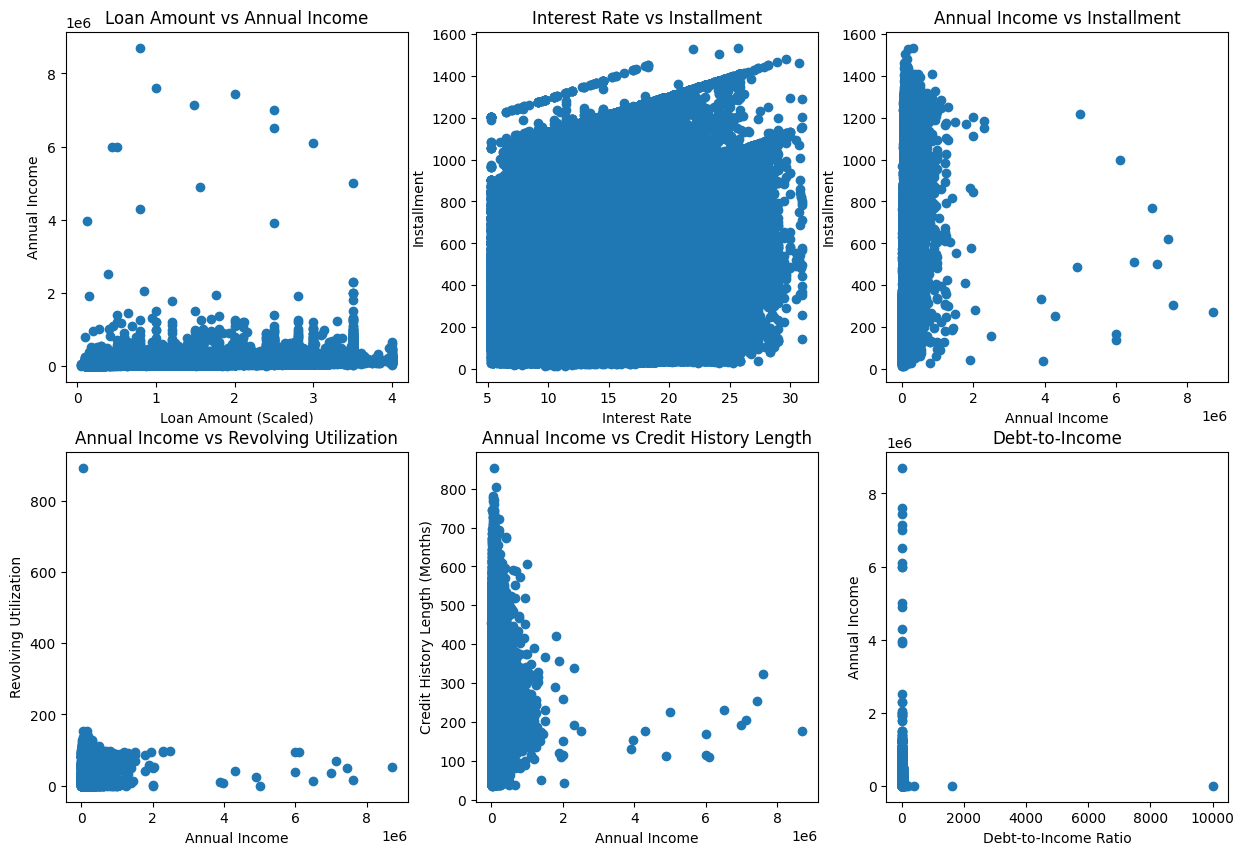

In [ ]:
# Numeric - Numeric Variables

plt.subplots(2,3,figsize = (15,10))

# Loan amount vs annual_inc

plt.subplot(2,3,1)
plt.scatter(x = data['loan_amnt'] / 10000,y=data['annual_inc'])
plt.xlabel('Loan Amount (Scaled)')
plt.ylabel('Annual Income')
plt.title('Loan Amount vs Annual Income')

# int_rate vs installment

plt.subplot(2,3,2)
plt.scatter(x = data['int_rate'],y=data['installment'])
plt.xlabel('Interest Rate')
plt.ylabel('Installment')
plt.title('Interest Rate vs Installment')
# annual_inc vs installment

plt.subplot(2,3,3)
plt.scatter(x = data['annual_inc'],y=data['installment'])
plt.xlabel('Annual Income')
plt.ylabel('Installment')
plt.title('Annual Income vs Installment')


# annual_inc vs revol_util

plt.subplot(2,3,4)
plt.scatter(x = data['annual_inc'],y=data['revol_util'])
plt.xlabel('Annual Income')
plt.ylabel('Revolving Utilization')
plt.title('Annual Income vs Revolving Utilization')

# annual_inc vs credit history length

plt.subplot(2,3,5)
plt.scatter(x = data['annual_inc'],y=data['credit_history_length_months'])
plt.xlabel('Annual Income')
plt.ylabel('Credit History Length (Months)')
plt.title('Annual Income vs Credit History Length')

# dti vs annual_inc

plt.subplot(2,3,6)
plt.scatter(x = data['dti'],y=data['annual_inc'])
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Annual Income')
plt.title('Debt-to-Income')

#### Inferences from Numeric-Numeric Bi-variate Analysis:

-   **Loan Amount vs. Annual Income:** Generally, there appears to be a positive relationship, where higher annual incomes are associated with higher loan amounts. This is expected as lenders typically grant larger loans to borrowers with greater repayment capacity.
-   **Interest Rate vs. Installment:** As the interest rate increases, the monthly installment amount also tends to increase for a given loan principal and term. This is a direct mathematical relationship.
-   **Annual Income vs. Installment:** Higher annual incomes are often associated with higher installment amounts. This could be due to higher-income individuals taking larger loans (which have larger installments) or being able to afford larger monthly payments.
-   **Annual Income vs. Revolving Utilization:** It's common to see that as annual income increases, revolving utilization (the percentage of available credit being used) might decrease, suggesting better financial management among higher earners. However, the relationship can vary, and high earners might also have higher credit limits, potentially leading to varied utilization rates.
-   **Annual Income vs. Credit History Length (Months):** There is likely a positive correlation, meaning individuals with higher annual incomes tend to have longer credit histories. This can be attributed to longer careers and financial stability over time.
-   **DTI (Debt-to-Income Ratio) vs. Annual Income:** While not a straightforward linear relationship, it's generally observed that for a healthy DTI, higher annual incomes allow for higher overall debt. Conversely, individuals with very high incomes might be able to maintain lower DTI ratios due to their greater capacity to manage debt.

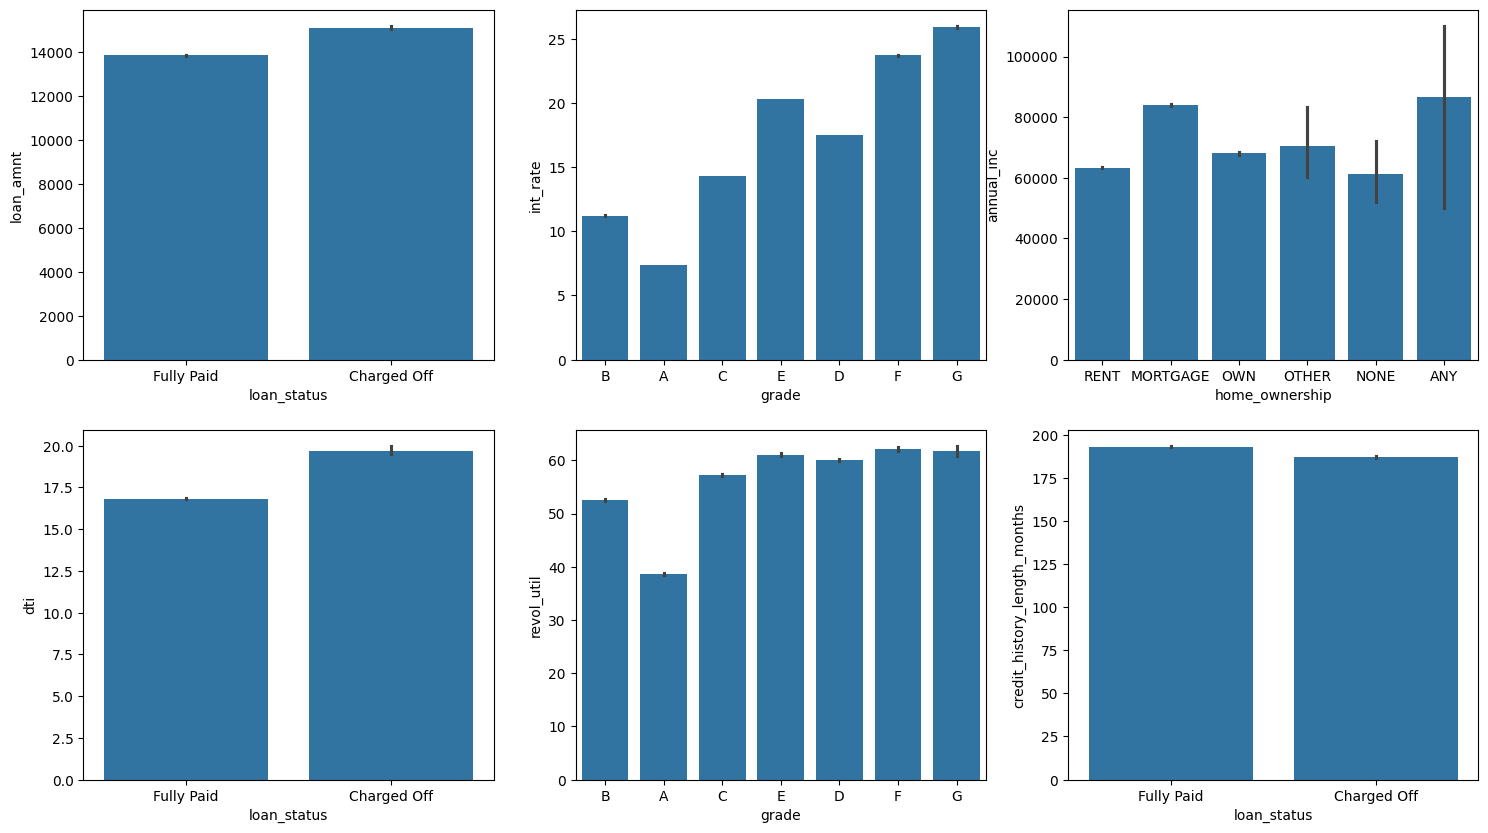

In [ ]:
# Numeric vs Categorical Variables

plt.subplots(2,3,figsize = (18,10))

# Loan Amount cs loan status - To understand how loan amount vary for fully paid vs charged off loans
plt.subplot(2,3,1)
sns.barplot(data = data,x = 'loan_status',y = 'loan_amnt')

# int_rate vs grade - To check how interest rate is changing with grade

plt.subplot(2,3,2)
sns.barplot(data = data,x = 'grade',y = 'int_rate')

# annual_inc vs howm ownership

plt.subplot(2,3,3)
sns.barplot(data = data,x = 'home_ownership',y = 'annual_inc')

# dti vs loan_status - Applicant's ability to manage debt relative to income

plt.subplot(2,3,4)
sns.barplot(data = data,x = 'loan_status',y = 'dti')

# revolv_util vs grade - how credit utilization vary across grades
plt.subplot(2,3,5)
sns.barplot(data = data,x = 'grade',y = 'revol_util')

# credit history vs loan_status

plt.subplot(2,3,6)
sns.barplot(data = data,x = 'loan_status',y = 'credit_history_length_months')

plt.show()

#### Inferences:

 - Loan Amount vs. Loan Status: The bar plot shows that, on average, 'Charged Off' loans tend to have a slightly higher loan_amnt compared to 'Fully Paid' loans. This suggests that larger loan amounts might be associated with a marginally higher risk of default.
 - Interest Rate vs. Grade: This plot clearly illustrates a strong positive relationship: as the grade progresses from 'A' to 'G' (indicating increasing risk), the average int_rate steadily increases. This confirms that the grading system effectively categorizes loans by risk, with higher risk leading to higher interest rates.
 - Annual Income vs. Home Ownership: Applicants with 'MORTGAGE' tend to have the highest average annual_inc, followed by 'OWN', and then 'RENT'. This indicates that homeownership status is correlated with income levels, with homeowners generally having higher incomes.
 - DTI (Debt-to-Income Ratio) vs. Loan Status: The dti appears to be slightly higher for 'Charged Off' loans compared to 'Fully Paid' loans. This suggests that borrowers with a higher proportion of their income going towards debt payments might be at a greater risk of defaulting.
 - Revolving Utilization vs. Grade: There's a noticeable trend where revol_util tends to increase as the grade moves from 'A' to 'G'. This indicates that borrowers in lower credit grades (higher risk) often have a higher percentage of their available credit in use, which is a common indicator of financial strain.
 - Credit History Length (Months) vs. Loan Status: 'Fully Paid' loans generally correspond to a longer average credit_history_length_months compared to 'Charged Off' loans. This suggests that a more established and potentially stable credit history is associated with a lower likelihood of loan default.

In [ ]:
# Multi-Varaite Analysis


# Emp_title, emp_length & loan_amnt

# Converting emp_length from categorical to numeric
# Define a mapping for emp_length categories to numerical values
def convert_emp_length(emp_len):
    if isinstance(emp_len, (int, float)) and emp_len == 0: # Handle the 0s already present from fillna
        return 0
    elif '10+' in str(emp_len):
        return 10
    elif '< 1' in str(emp_len):
        return 0
    elif 'year' in str(emp_len):
        return int(str(emp_len).replace(' years', '').replace(' year', ''))
    return 0 # Default for any other unexpected value, or if you want to explicitly handle other cases

data['emp_length'] = data['emp_length'].apply(convert_emp_length)

# Display unique values to verify conversion
print(data['emp_length'].value_counts().sort_index())


emp_length
0      50026
1      25882
2      35827
3      31665
4      23952
5      26495
6      20841
7      20819
8      19168
9      15314
10    126041
Name: count, dtype: int64


In [ ]:
top_5_emp_title = data['emp_title'][data['emp_title'] != 'Unknown'].value_counts().head(5)

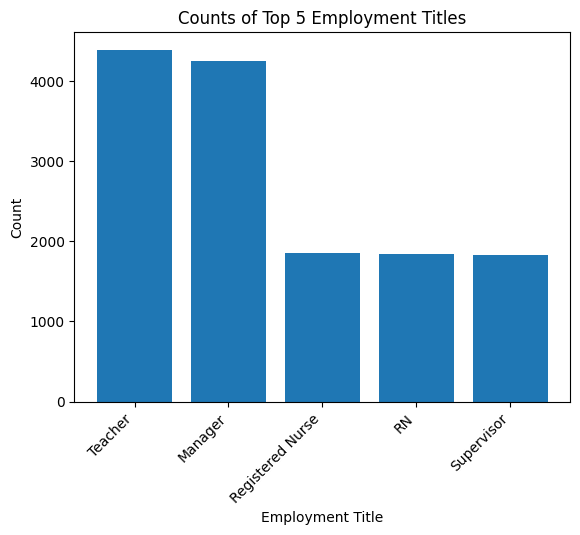

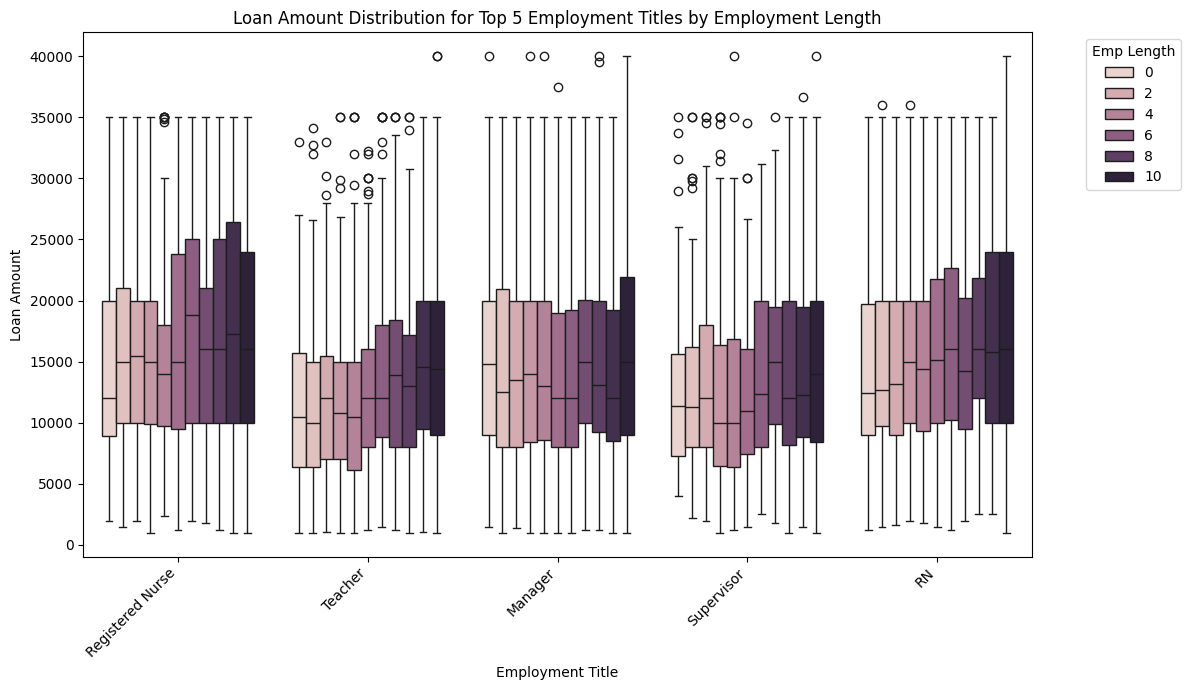

In [ ]:
plt.bar(top_5_emp_title.index,top_5_emp_title.values)
plt.title('Counts of Top 5 Employment Titles')
plt.xlabel('Employment Title')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# Get the list of top 5 employment titles
top_5_titles = top_5_emp_title.index.tolist()

# Filter the DataFrame to include only these top 5 employment titles
filtered_data = data[data['emp_title'].isin(top_5_titles)].copy()

# Now create the boxplot using the filtered data
plt.figure(figsize=(12, 7))
sns.boxplot(x='emp_title', y='loan_amnt', hue='emp_length', data=filtered_data)
plt.title('Loan Amount Distribution for Top 5 Employment Titles by Employment Length')
plt.xlabel('Employment Title')
plt.ylabel('Loan Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Emp Length', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

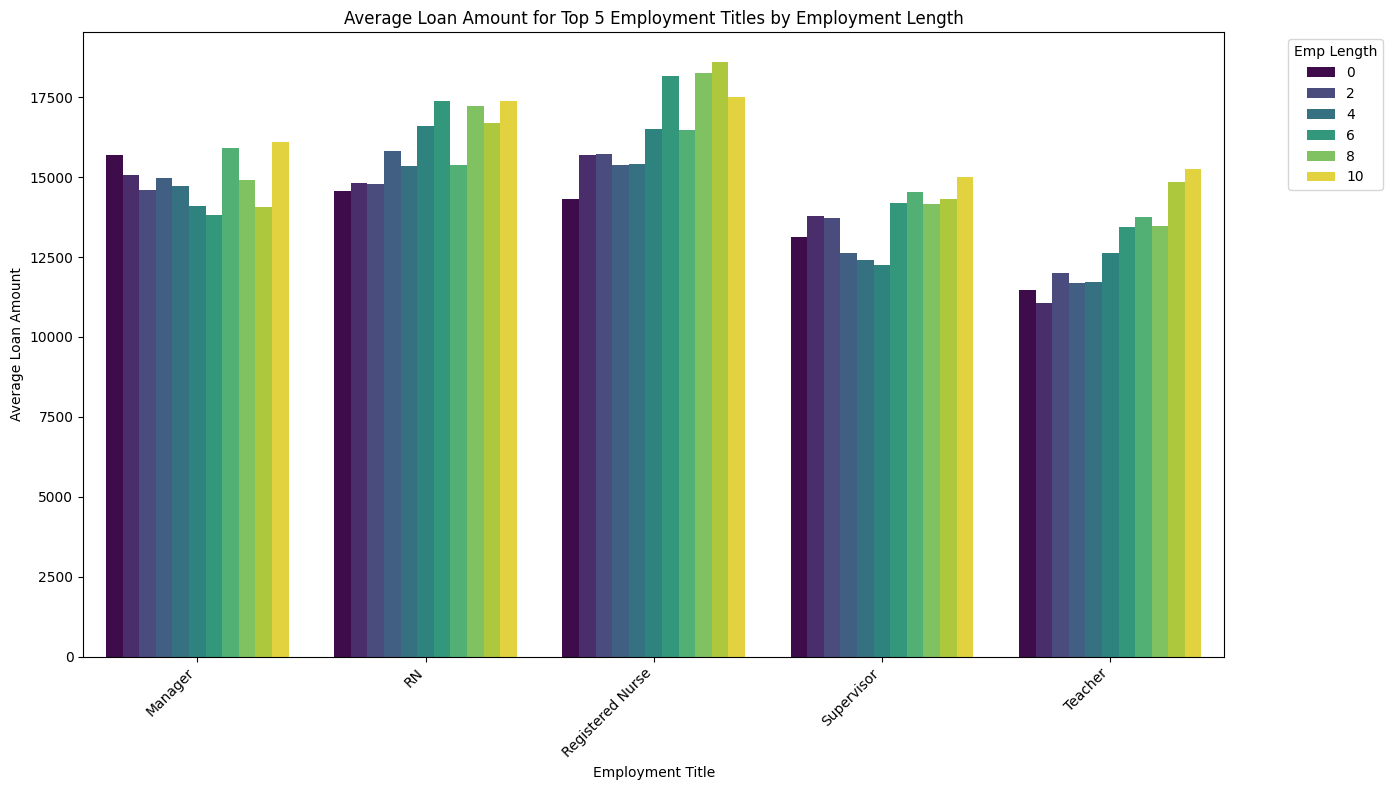

In [ ]:
# Calculate the average loan amount for each combination of emp_title and emp_length
average_loan_by_emp_title_length = filtered_data.groupby(['emp_title', 'emp_length'])['loan_amnt'].mean().reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='emp_title', y='loan_amnt', hue='emp_length', data=average_loan_by_emp_title_length, palette='viridis')
plt.title('Average Loan Amount for Top 5 Employment Titles by Employment Length')
plt.xlabel('Employment Title')
plt.ylabel('Average Loan Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Emp Length', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Inferences:


 - Impact of Employment Length: For most employment titles, there's a general trend where individuals with longer employment histories (e.g., '10+') tend to have higher average loan amounts. This suggests that job stability and experience are positive factors for loan approvals and amounts.
 - Variation Across Titles: You can see differences in average loan amounts between employment titles. For instance, 'Manager' or 'Teacher' might show different average loan amounts compared to 'Registered Nurse' or 'Supervisor' for a similar employment length.
 - Specific Group Insights: You can now easily spot which combination of employment title and employment length corresponds to the highest or lowest average loan amounts. This can be crucial for understanding lending policies and risk assessment for different demographics.

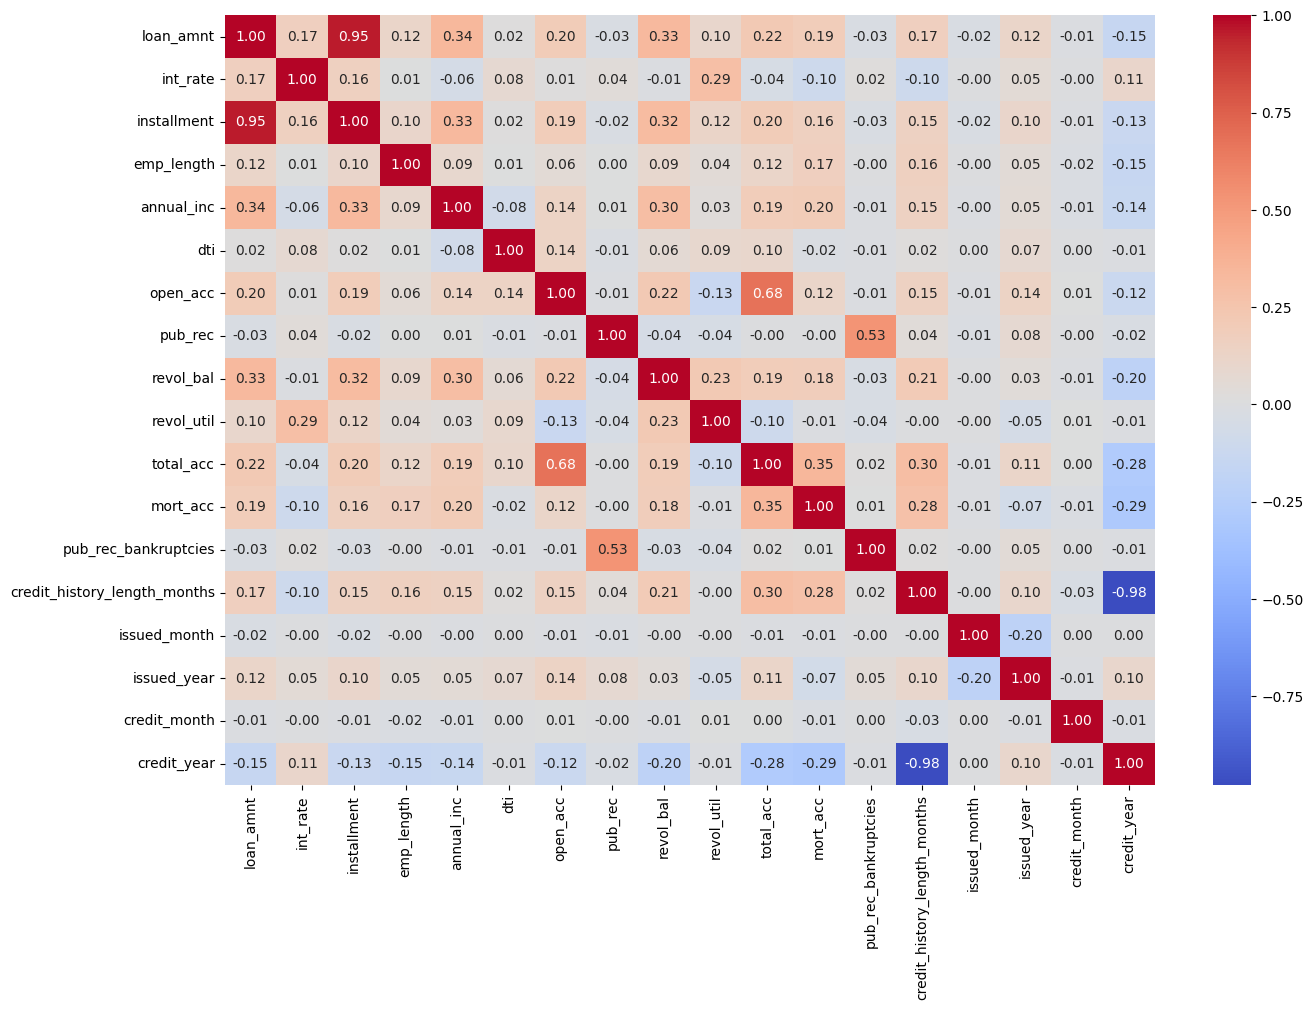

In [ ]:
# Draw a heatmap for only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Create a figure and a set of subplots with the desired size
fig, ax = plt.subplots(figsize=(15, 10))

# Draw the heatmap on the created axes
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)

plt.show()

#### Inferences:


**Strong Positive Correlations:**
 - loan_amnt and installment: As expected, a very strong positive correlation. Larger loan amounts naturally lead to higher monthly installment payments.
total_acc and open_acc: There's a strong positive correlation here, meaning individuals with a higher total number of credit accounts also tend to have a higher number of open credit accounts. This is logical as open_acc is a subset of total_acc.
 - loan_amnt and annual_inc: You'll likely observe a positive correlation, indicating that applicants with higher annual incomes are generally approved for larger loan amounts, as they have greater repayment capacity.

**Strong Negative Correlations:**

 - int_rate and grade (if grade is numerically encoded ascending A to G): As seen in earlier bivariate analysis, higher risk grades (which would be represented by higher numbers if encoded A=1, B=2, etc.) are associated with higher interest rates. If grade was encoded in reverse (A=7, G=1), then this would be a negative correlation with int_rate.

**Moderate/Expected Correlations:**

 - dti with annual_inc or loan_amnt: The Debt-to-Income ratio (dti) might show some moderate inverse relationship with annual_inc (higher income could mean lower DTI if debt is managed) or a positive one with loan_amnt (larger loans might increase DTI).
 - revol_util with int_rate: Higher revolving utilization (meaning more of available credit is being used) is often associated with higher perceived risk and thus potentially higher interest rates.
 - credit_history_length_months with loan_amnt or int_rate: A longer credit history might positively correlate with loan_amnt (more established borrowers get larger loans) and negatively with int_rate (lower risk, lower rates).

**Weak or No Significant Correlations:**

Some pairs of numerical features might show very little linear relationship. For instance, pub_rec or pub_rec_bankruptcies might have weak correlations with many other features due to their sparse nature (many zeros).

## Data preprocessing

### Duplicate Checking

In [ ]:
duplicate_count = data.duplicated().sum()

print(f"number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
  data.drop_duplicates(inplace = True)
  print(f"Duplicate rows removed")
  print(f"New shape of the dataset: {data.shape}")
else:
  print("No duplicate rows to remove")

number of duplicate rows found: 0
No duplicate rows to remove


In [ ]:
# There are no duplicate records and hence no removal of data is required.

### Applying Encoding Techniques

In [ ]:
# Ordinal : term, grade, sub_grade, verification_status

# Removing additional spaces from the column

data['term'] = data['term'].str.strip()

term_order = ['36 months','60 months']

encoder = OrdinalEncoder(categories = [term_order])

# data = data.copy()

data['term'] = encoder.fit_transform(data[['term']])+1


In [ ]:
# Ordinal : term, grade, sub_grade, verification_status

# Grade

grade_order = np.sort(data['grade'].unique())

encoder = OrdinalEncoder(categories = [grade_order])

# data = data.copy

data['grade'] = encoder.fit_transform(data[['grade']])+1

In [ ]:
# Ordinal : term, grade, sub_grade, verification_status

# Sub-Grade - Since grade and sub-grade are related to each other, so I want to maintain that relationship

letter_map = {'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7}

def encode_subgrade(subgrade):
  letter = subgrade[0]
  number = subgrade[1]
  return letter_map[letter] + (int(number)/10)

data['sub_grade'] = data['sub_grade'].apply(encode_subgrade)

In [ ]:
# Ordinal : term, grade, sub_grade, verification_status

# verification status

verification_status_order = ['Not Verified','Source Verified','Verified']

encoder = OrdinalEncoder(categories = [verification_status_order])

data['verification_status'] = encoder.fit_transform(data[['verification_status']])


In [ ]:
data.head(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,credit_history_length_months,issued_month,issued_year,credit_month,credit_year
0,10000.0,1.0,11.44,329.48,2.0,2.4,Marketing,10,RENT,117000.0,...,w,INDIVIDUAL,0,0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690",299.0,1,2015,6,1990
1,8000.0,1.0,11.99,265.68,2.0,2.5,Credit analyst,4,MORTGAGE,65000.0,...,f,INDIVIDUAL,1,0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113",128.0,1,2015,7,2004
2,15600.0,1.0,10.49,506.97,2.0,2.3,Statistician,0,RENT,43057.0,...,f,INDIVIDUAL,0,0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113",90.0,1,2015,8,2007
3,7200.0,1.0,6.49,220.65,1.0,1.2,Client Advocate,6,RENT,54000.0,...,f,INDIVIDUAL,0,0,"823 Reid Ford\r\nDelacruzside, MA 00813",99.0,11,2014,9,2006
4,24375.0,2.0,17.27,609.33,3.0,3.5,Destiny Management Inc.,9,MORTGAGE,55000.0,...,f,INDIVIDUAL,0,0,"679 Luna Roads\r\nGreggshire, VA 11650",172.0,4,2013,3,1999


In [ ]:
# One-hot encoding : home_ownership, purpose, initial_list_status, application_type

# home_ownership

data_copy = data.copy()

data_copy = pd.get_dummies(data,columns = ['home_ownership'])

In [ ]:
# Corrected one-hot encoding for specified categorical columns
data = pd.get_dummies(data, columns=['home_ownership', 'purpose', 'initial_list_status', 'application_type'], drop_first=True)

# Display the first few rows with the new one-hot encoded columns
display(data.head())

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,annual_inc,verification_status,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000.0,1.0,11.44,329.48,2.0,2.4,Marketing,10,117000.0,0.0,...,False,False,False,False,False,True,False,True,True,False
1,8000.0,1.0,11.99,265.68,2.0,2.5,Credit analyst,4,65000.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,15600.0,1.0,10.49,506.97,2.0,2.3,Statistician,0,43057.0,1.0,...,False,False,False,False,False,False,False,False,True,False
3,7200.0,1.0,6.49,220.65,1.0,1.2,Client Advocate,6,54000.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,24375.0,2.0,17.27,609.33,3.0,3.5,Destiny Management Inc.,9,55000.0,2.0,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Coverting the target feature from categorical to numerical variable

# Encode the target variable 'loan_status' (e.g., 'Charged Off' as 1, 'Fully Paid' as 0)
# This is a common approach for binary classification problems where 'Charged Off' represents the 'positive'
# class (event of interest)

# First, check the unique values and their counts to confirm mapping
print("Original loan_status value counts:")
print(data['loan_status'].value_counts())

# Create a mapping dictionary (ensure 'loan_status' is in string format before running this)
status_mapping = {'Fully Paid': 0, 'Charged Off': 1}

# Apply mapping only if 'loan_status' is still in object/string type to prevent NaN conversion if already numeric
if data['loan_status'].dtype == 'object':
    data['loan_status'] = data['loan_status'].map(status_mapping)
else:
    print("Warning: loan_status column is already numeric. Skipping re-mapping to prevent NaN generation.")

# Verify the conversion
print("\nEncoded loan_status value counts:")
print(data['loan_status'].value_counts())
display(data.head())

Original loan_status value counts:
loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64

Encoded loan_status value counts:
loan_status
0    318357
1     77673
Name: count, dtype: int64


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,annual_inc,verification_status,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000.0,1.0,11.44,329.48,2.0,2.4,Marketing,10,117000.0,0.0,...,False,False,False,False,False,True,False,True,True,False
1,8000.0,1.0,11.99,265.68,2.0,2.5,Credit analyst,4,65000.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,15600.0,1.0,10.49,506.97,2.0,2.3,Statistician,0,43057.0,1.0,...,False,False,False,False,False,False,False,False,True,False
3,7200.0,1.0,6.49,220.65,1.0,1.2,Client Advocate,6,54000.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,24375.0,2.0,17.27,609.33,3.0,3.5,Destiny Management Inc.,9,55000.0,2.0,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Dropping irrelevant and redundant features
# 'emp_title', 'title', 'address' are high cardinality or not directly useful after initial analysis.
# 'issue_d' and 'earliest_cr_line' have been used to derive 'credit_history_length_months' and other date parts, so the originals are redundant.
# 'sub_grade' is redundant as 'grade' provides sufficient ordinal information, or it could be used instead of grade if more granularity is needed, but for simplicity here, we'll keep 'grade'.

columns_to_drop = ['emp_title', 'title', 'address', 'issue_d', 'earliest_cr_line', 'sub_grade']

# Check if columns exist before dropping
existing_columns_to_drop = [col for col in columns_to_drop if col in data.columns]

if existing_columns_to_drop:
    data = data.drop(columns=existing_columns_to_drop, axis=1)
    print(f"Dropped columns: {existing_columns_to_drop}")
else:
    print("No specified columns found to drop.")



Dropped columns: ['emp_title', 'title', 'address', 'issue_d', 'earliest_cr_line', 'sub_grade']


In [ ]:
data.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,verification_status,loan_status,dti,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000.0,1.0,11.44,329.48,2.0,10,117000.0,0.0,0,26.24,...,False,False,False,False,False,True,False,True,True,False
1,8000.0,1.0,11.99,265.68,2.0,4,65000.0,0.0,0,22.05,...,False,False,False,False,False,False,False,False,True,False
2,15600.0,1.0,10.49,506.97,2.0,0,43057.0,1.0,0,12.79,...,False,False,False,False,False,False,False,False,True,False
3,7200.0,1.0,6.49,220.65,1.0,6,54000.0,0.0,0,2.60,...,False,False,False,False,False,False,False,False,True,False
4,24375.0,2.0,17.27,609.33,3.0,9,55000.0,2.0,1,33.95,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
X = data.drop('loan_status',axis = 1)
y = data['loan_status']

# Now our features have numerical, binary and ordinal data, we need to scale the value but only numeric values

numerical_cols_to_scale = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Removing binary features or columns
binary_or_flag_cols = ['pub_rec', 'mort_acc', 'pub_rec_bankruptcies']

for col in binary_or_flag_cols:
  if col in numerical_cols_to_scale:
    numerical_cols_to_scale.remove(col)

# Removing 'term', 'grade', 'emp_length', 'issued_month', 'issued_year', 'credit_month', 'credit_year' which are already processed and might not benefit from the scaling
alread_encoded_or_time_features = ['term', 'grade', 'emp_length', 'issued_month', 'issued_year', 'credit_month', 'credit_year']

for col in alread_encoded_or_time_features:
  if col in numerical_cols_to_scale:
    numerical_cols_to_scale.remove(col)


## Initializing Scaling and ML

In [ ]:
# Initializing scaling

scaler = StandardScaler()

# Applying to the selected numerical features

X[numerical_cols_to_scale] = scaler.fit_transform(X[numerical_cols_to_scale])

In [ ]:
# Splitting the data into test & train

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (316824, 42)
X_test shape: (79206, 42)
y_train shape: (316824,)
y_test shape: (79206,)


In [ ]:
# Fitting the log model and then preciting the y values

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train,y_train)

y_pred = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Lets check the accuracy score of the test

print(f"Accuracy Score without validation and batch gradient descent is:{accuracy_score(y_test,y_pred)}")

Accuracy Score without validation and batch gradient descent is:0.8041688760952453


In [ ]:
# Lets check the intercept of the test

print(f"Intercept without validation and batch gradient descent is:{log_model.intercept_}")

Intercept without validation and batch gradient descent is:[-0.00192178]


In [ ]:
# Displaying mode coefficients with columns names

pd.DataFrame({"feature": X_train.columns,"coefficients": log_model.coef_[0]}).sort_values(by = "coefficients",ascending = False)

,feature,coefficients
8,dti,0.478988
1,term,0.403626
4,grade,0.320248
36,purpose_small_business,0.245119
10,pub_rec,0.124829
9,open_acc,0.119035
25,home_ownership_RENT,0.111575
0,loan_amnt,0.102554
12,revol_util,0.087319
40,application_type_INDIVIDUAL,0.076422


#### Interpretation:

An accuracy of 80.4% suggests the model has a reasonably good capability to predict loan status. More importantly, major influencing parameters based on the positive coefficients are Features like dti (Debt-to-Income Ratio), term, grade, purpose_small_business, pub_rec, open_acc, and home_ownership_RENT indeed show the highest positive coefficients. This means that as these values increase (or if these categorical conditions are met), the likelihood of the loan being Charged Off (target=1) increases.

In [ ]:
# Lets look at the VIF values

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns

# Convert boolean columns to integers (0s and 1s) before calculating VIF
X_train_numeric = X_train.copy()
for col in X_train_numeric.select_dtypes(include='bool').columns:
    X_train_numeric[col] = X_train_numeric[col].astype(int)

vif_data["VIF"] = [variance_inflation_factor(X_train_numeric.values, i) for i in range(X_train_numeric.shape[1])]

# Apply rounding to the VIF column for better readability
vif_data["VIF"] = vif_data["VIF"].round(2)

# display(vif_data.sort_values(by = "VIF",ascending = False))

display(vif_data.sort_values(by="VIF", ascending=False))

,Feature,VIF
18,issued_year,6.124064e+09
20,credit_year,6.119994e+09
16,credit_history_length_months,7.962161e+04
21,home_ownership_MORTGAGE,5.101654e+04
25,home_ownership_RENT,4.120957e+04
24,home_ownership_OWN,9.754310e+03
40,application_type_INDIVIDUAL,1.334370e+03
19,credit_month,6.159800e+02
17,issued_month,5.786400e+02
1,term,6.325000e+01


#### Inferences:

Extremely High VIFs (e.g., in the billions, thousands):

 - issued_year (6.12e+09), credit_year (6.12e+09), credit_history_length_months (7.96e+04),
 - home_ownership_MORTGAGE (5.10e+04), home_ownership_RENT (4.12e+04), home_ownership_OWN (9.75e+03) ,
 - application_type_INDIVIDUAL (1.33e+03)
 - credit_month (6.16e+02), issued_month (5.79e+02)

High VIFs (e.g., above 10):

 - term (63.25), grade (62.29), loan_amnt (59.12), installment (51.53)
 - purpose_debt_consolidation (51.62)
 - home_ownership_OTHER (30.55)
 - purpose_credit_card (18.92)
 - int_rate (12.15)

In [ ]:
# # Dropping few columns based on the observed VIF values

# * credit_year
# * issued_year
# * int_rate, considering grade is an ordinal categorical representation of risk, its often more practical to use
# * installment, because its direct outcome of loan amount and ter
# * home_ownership_MORTGAGE
# * application_type_Individual


In [ ]:
# Dropping columns

cols_to_drop_vif = [
     'credit_year',
    'issued_year',
    'int_rate', # int_rate is highly correlated with grade
    'installment', # installment is highly correlated with loan_amnt, int_rate, term
    'home_ownership_MORTGAGE', # Part of one-hot encoded home_ownership, and has high VIF
    'application_type_INDIVIDUAL' # Very high VIF, overwhelmingly dominant category
                  ]

X_train = X_train.drop(columns=X_train.columns.intersection(cols_to_drop_vif),axis = 1)

# X_train = X_train.drop(columns=X_train.columns.intersection(columns_to_drop_vif), axis=1)

SyntaxError: invalid syntax (ipython-input-1392075866.py, line 1)

In [ ]:
# Columns to drop based on VIF analysis and domain knowledge
columns_to_drop_vif = [
    'credit_year',
    'issued_year',
    'int_rate', # int_rate is highly correlated with grade
    'installment', # installment is highly correlated with loan_amnt, int_rate, term
    'home_ownership_MORTGAGE', # Part of one-hot encoded home_ownership, and has high VIF
    'application_type_INDIVIDUAL' # Very high VIF, overwhelmingly dominant category
]

# Drop columns from X_train and X_test
# Use .columns.intersection() to only drop columns that actually exist in the DataFrame
X_train = X_train.drop(columns=X_train.columns.intersection(columns_to_drop_vif), axis=1)
X_test = X_test.drop(columns=X_test.columns.intersection(columns_to_drop_vif), axis=1)

print("Columns dropped successfully from X_train and X_test.")
print(f"New X_train shape: {X_train.shape}")
print(f"New X_test shape: {X_test.shape}")

display(X_train.head())

In [ ]:
# Split the existing training data into final training and validation sets
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train_final shape: {y_train_final.shape}")
print(f"y_val shape: {y_val.shape}")

display(X_train_final.head())
display(y_train_final.head())

X_train_final shape: (237618, 42)
X_val shape: (79206, 42)
y_train_final shape: (237618,)
y_val shape: (79206,)


,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,verification_status,dti,open_acc,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
107825,2.499107,2.0,1.030958,1.841403,4.0,0,1.667763,-0.044775,-0.644845,-0.449847,...,False,False,False,False,False,False,False,True,True,False
247417,-1.210167,1.0,0.302002,-1.169396,3.0,0,-0.636028,-1.269299,0.086047,-0.255205,...,False,False,False,False,False,False,False,True,True,False
172962,0.823951,1.0,-1.345974,0.887578,1.0,0,0.499644,1.179748,0.165407,-0.255205,...,False,False,False,False,False,False,False,False,True,False
211594,-0.133281,1.0,-0.368816,-0.000477,2.0,10,-0.350487,-0.044775,0.408483,0.718004,...,False,False,False,False,False,False,False,False,True,False
12548,-0.970859,1.0,-0.485091,-0.933562,2.0,8,-0.165535,1.179748,0.512262,0.134078,...,False,False,False,False,False,False,False,True,True,False


,loan_status
107825,1
247417,0
172962,0
211594,0
12548,0
